In [1]:
import numpy as np
import xarray as xr
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [2]:
exp_num_era5 = 1
exp_num_icon = 6

filename_era5 = '/Users/yunpeichu/work_dales/mpc_seed/era5/run_{0:03d}/mpc_seed_les_input.nc'.format(exp_num_era5)
filename_icon = '/Users/yunpeichu/work_dales/mpc_seed/run_{0:03d}/ICON_reglatlon_les_input.nc'.format(exp_num_icon)

ds_era5 = xr.open_dataset(filename_era5)
ds_icon = xr.open_dataset(filename_icon)

In [3]:
def interpolate_vertical_profiles(ds_src, ds_tgt, var_names, 
                                  src_p_name='p_lay', tgt_p_name='p_lay', 
                                  time_idx=0, output_filename=None):
    """
    Interpolates a LIST of variables from source to target vertical grid 
    based on pressure coordinates.

    Parameters:
    - ds_src: Source xarray Dataset (e.g., ds_era5)
    - ds_tgt: Target xarray Dataset (e.g., ds_icon)
    - var_names: List of variable names to interpolate (e.g., ['o3_lay', 't', 'qv'])
    - src_p_name: Name of pressure variable in source (default: 'p_lay')
    - tgt_p_name: Name of pressure variable in target (default: 'p_lay')
    - time_idx: Time index to select (default: 0)
    - output_filename: If provided, saves the result to this NetCDF file.
    
    Returns:
    - ds_tgt: The modified target dataset containing the new interpolated variables.
    """
    
    # 1. Prepare Pressure Coordinates
    # Handle Source Pressure
    if 'time' in ds_src[src_p_name].dims:
        src_p = ds_src[src_p_name].isel(time=time_idx).values
    else:
        src_p = ds_src[src_p_name].values

    # Handle Target Pressure
    if 'time' in ds_tgt[tgt_p_name].dims:
        tgt_p = ds_tgt[tgt_p_name].isel(time=time_idx).values
        # Get target dimension object for later assignment
        tgt_dims_obj = ds_tgt[tgt_p_name].isel(time=time_idx)
    else:
        tgt_p = ds_tgt[tgt_p_name].values
        tgt_dims_obj = ds_tgt[tgt_p_name]

    # Get the primary dimension name (e.g., 'lay', 'height', 'level')
    primary_dim_name = tgt_dims_obj.dims[0]

    # 2. Sort Source Indices once (Efficiency step)
    # interp1d requires monotonically increasing x-values
    sort_indices = np.argsort(src_p)
    src_p_sorted = src_p[sort_indices]

    # 3. Loop over all requested variables
    for var in var_names:
        if var not in ds_src:
            print(f"Warning: Variable '{var}' not found in source dataset. Skipping.")
            continue
            
        # Extract Source Data
        if 'time' in ds_src[var].dims:
            src_data = ds_src[var].isel(time=time_idx).values
        else:
            src_data = ds_src[var].values
        
        # Sort Data to match sorted Pressure
        src_data_sorted = src_data[sort_indices]

        # Interpolate
        f = interp1d(src_p_sorted, src_data_sorted, kind='linear', 
                     bounds_error=False, fill_value="extrapolate")
        interpolated_values = f(tgt_p)

        # Assign to Target Dataset
        ds_tgt[var] = xr.DataArray(
            data=interpolated_values,
            coords={primary_dim_name: ds_tgt[primary_dim_name]},
            dims=(primary_dim_name),
            attrs=ds_src[var].attrs  # Preserve units/long_name
        )
        print(f"Interpolated: {var}")

    # 4. Save to Disk (Once, after all vars are added)
    if output_filename:
        ds_tgt.to_netcdf(output_filename)
        print(f"Saved modified dataset to: {output_filename}")
    
    return ds_tgt

In [5]:
vars_to_process = ['p_lay', 't_lay', 'qv_lay', 'ql_lay']
ds_era5_backrad = interpolate_vertical_profiles(
    ds_src=ds_icon, 
    ds_tgt=ds_era5, 
    var_names=vars_to_process,
    output_filename='/Users/yunpeichu/work_dales/mpc_seed/era5/run_001/ERA5.backrad.inp.nc'
)

Interpolated: p_lay
Interpolated: t_lay
Interpolated: qv_lay
Interpolated: ql_lay
Saved modified dataset to: /Users/yunpeichu/work_dales/mpc_seed/era5/run_001/ERA5.backrad.inp.nc


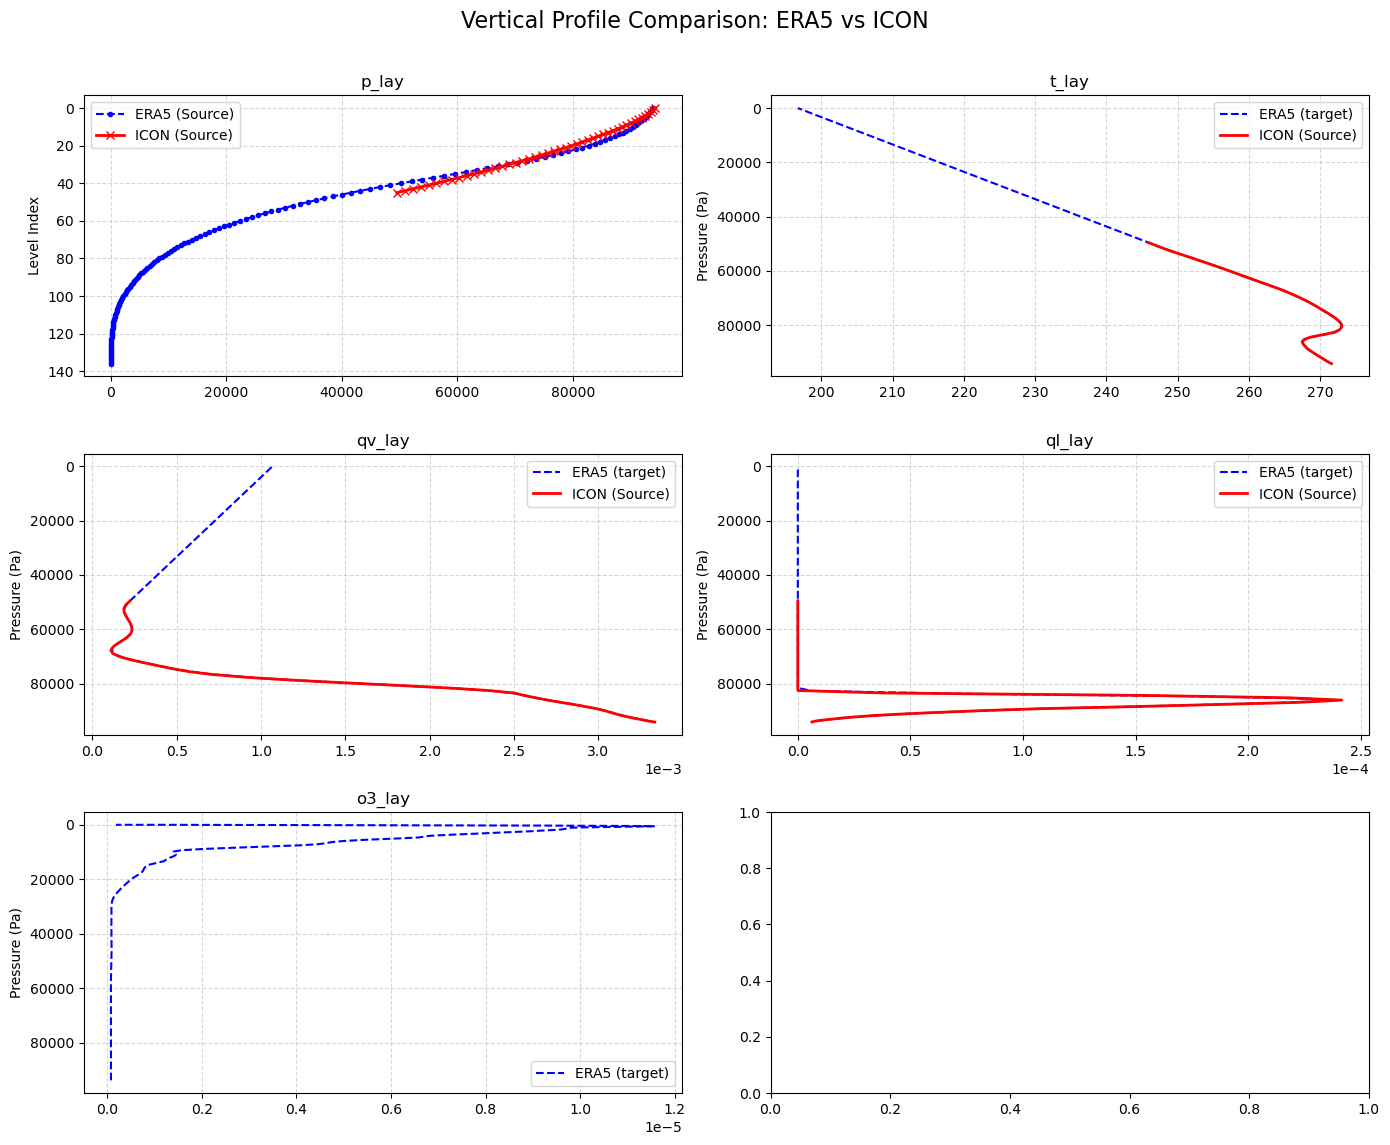

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
vars_to_process = ['p_lay', 't_lay', 'qv_lay', 'ql_lay', 'o3_lay']
# Extract Pressure coordinates for y-axis plotting
# (ERA5 pressure for ERA5 data, ICON pressure for ICON data)
p_era5 = ds_era5_backrad['p_lay'].isel(time=0).values if 'time' in ds_era5_backrad['p_lay'].dims else ds_era5_backrad['p_lay'].values
p_icon = ds_icon['p_lay'].isel(time=0).values if 'time' in ds_icon['p_lay'].dims else ds_icon['p_lay'].values

for i, var in enumerate(vars_to_process):
    ax = axes[i]
    
    # --- 1. Plot ERA5 (Source) ---
    if var in ds_era5_backrad:
        # Get data
        data_era = ds_era5_backrad[var].isel(time=0) if 'time' in ds_era5_backrad[var].dims else ds_era5_backrad[var]
        
        # Special handling for 'p_lay': Plot against Index to show grid spacing
        if var == 'p_lay':
            ax.plot(data_era, np.arange(len(data_era)), 'b--', label='ERA5 (Source)', marker='.')
            ax.set_ylabel('Level Index')
            ax.invert_yaxis() # Top level is usually index 0 or similar
        else:
            # Standard Profile: Value vs Pressure
            ax.plot(data_era, p_era5, 'b--', label='ERA5 (target)')
            ax.set_ylabel('Pressure (Pa)')
            # ax.set_yscale('log')
            ax.invert_yaxis() # High pressure at bottom
    
    # --- 2. Plot ICON (Interpolated Target) ---
    if var in ds_icon:
        # Get data
        data_icon = ds_icon[var].isel(time=0) if 'time' in ds_icon[var].dims else ds_icon[var]
        
        if var == 'p_lay':
            ax.plot(data_icon, np.arange(len(data_icon)), 'r-', linewidth=2, label='ICON (Source)', marker='x')
        else:
            ax.plot(data_icon, p_icon, 'r-', linewidth=2, label='ICON (Source)')

    # --- 3. Styling ---
    ax.set_title(var)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()
    
    # Special Formatting for Specific Humidity (qv) and Cloud Water (ql)
    # Convert small kg/kg numbers to scientific notation on x-axis
    if 'qv' in var or 'ql' in var:
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.suptitle("Vertical Profile Comparison: ERA5 vs ICON", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()